# MuSe 2021 Data Understanding and Inspection

This notebook is the first project checkpoint before preprocessing or modeling. It inspects the local `MuSe-Physio` and `MuSe-Stress` folders and answers:

- Which subjects and splits are available?
- Which extracted feature folders or feature archives exist, and what dimensions do they have?
- What does each feature represent?
- Are labels available for train/devel/test?
- Are timestamps and rows aligned across modalities?
- Are the core physiological streams available for the teacher/student project?
- What edge cases must be handled before training?

No data is modified by this notebook. It reads CSVs directly from the existing zip archives.

## Assumptions to Verify

These are working assumptions, not final modeling decisions:

1. `MuSe-Physio` is the main dataset because it contains the `anno12_EDA` target.
2. `ECG`, `BPM`, and `resp` are the core physiological input streams available in the local feature package.
3. `egemaps`, `vggish`, `deepspectrum`, `fau_intensity`, `vggface`, and `bert` are optional multimodal features, not required for the first physiological-only model.
4. The first task should be continuous regression because labels are continuous values over time.
5. Official `test` labels are expected to be blank in the challenge package, so local evaluation should use `devel` or a custom subject-level split.

Run the checks below and update these assumptions if the outputs disagree.

## Arousal, Valence, and anno12_EDA

`label_segments` contains the target values, not model inputs. `arousal` measures emotional activation or intensity, while `valence` measures emotional positivity or negativity. `MuSe-Physio` uses `anno12_EDA`, a continuous EDA-informed arousal target. These labels should be handled as regression targets unless we deliberately create classes later by thresholding.


In [1]:
from pathlib import Path
import os
import re
import zipfile

import numpy as np
import pandas as pd

try:
    import matplotlib.pyplot as plt
    HAS_MATPLOTLIB = True
except Exception as exc:
    HAS_MATPLOTLIB = False
    print(f"Matplotlib is unavailable; plot cells will be skipped. Reason: {exc}")

pd.set_option("display.max_columns", 120)
pd.set_option("display.max_colwidth", 120)
pd.set_option("display.width", 160)

In [2]:
# Robust project-root detection.
# If this notebook is opened from /notebooks, move one level up. Otherwise use the current working directory.
PROJECT_ROOT = Path(os.environ.get("PROJECT_ROOT_OVERRIDE", Path.cwd())).resolve()
if PROJECT_ROOT.name.lower() == "notebooks":
    PROJECT_ROOT = PROJECT_ROOT.parent

DATA_ROOT = PROJECT_ROOT / "Data"

TASKS = {
    "MuSe-Physio": {
        "root": DATA_ROOT / "MuSe-Physio Multimodal Physiological-Arousal (MuSe2021)" / "c4_muse_physio" / "c4_muse_physio",
        "labels": ["anno12_EDA"],
        "primary_target": "anno12_EDA",
        "description": "Physiological arousal prediction; target is a continuous EDA-informed arousal annotation.",
    },
    "MuSe-Stress": {
        "root": DATA_ROOT / "MuSe-Stress Multimodal Emotional Stress (MuSe2021)" / "c3_muse_stress" / "c3_muse_stress",
        "labels": ["arousal", "valence"],
        "primary_target": "arousal",
        "description": "Stress/emotion prediction with continuous arousal and valence targets.",
    },
}

CORE_PHYSIO_FEATURES = ["ECG", "BPM", "resp"]
OPTIONAL_FEATURES = ["egemaps", "vggish", "deepspectrum", "fau_intensity", "vggface", "bert"]
EXPECTED_FEATURES = CORE_PHYSIO_FEATURES + OPTIONAL_FEATURES

FEATURE_CATALOG = pd.DataFrame([
    {"feature": "ECG", "group": "physiological", "dim_expected": 1, "represents": "Electrocardiogram / heart electrical activity.", "project_role": "Core input"},
    {"feature": "BPM", "group": "physiological", "dim_expected": 1, "represents": "Heart rate in beats per minute.", "project_role": "Core input"},
    {"feature": "resp", "group": "physiological", "dim_expected": 1, "represents": "Respiration signal.", "project_role": "Core input"},
    {"feature": "egemaps", "group": "audio", "dim_expected": 88, "represents": "Handcrafted acoustic descriptors such as pitch, loudness, MFCCs, jitter, shimmer, and voice-quality statistics.", "project_role": "Optional teacher/context feature"},
    {"feature": "vggish", "group": "audio", "dim_expected": 128, "represents": "Deep audio embeddings extracted with a VGGish-style network.", "project_role": "Optional teacher/context feature"},
    {"feature": "deepspectrum", "group": "audio-derived", "dim_expected": 4096, "represents": "Deep features from spectrogram images; high-dimensional audio/speech representation.", "project_role": "Optional teacher/context feature; expensive"},
    {"feature": "fau_intensity", "group": "visual", "dim_expected": 17, "represents": "Facial Action Unit intensity features from video frames.", "project_role": "Optional teacher/context feature"},
    {"feature": "vggface", "group": "visual", "dim_expected": 512, "represents": "Deep face embeddings from video frames.", "project_role": "Optional teacher/context feature"},
    {"feature": "bert", "group": "text", "dim_expected": 768, "represents": "BERT embeddings from transcribed speech/text.", "project_role": "Optional teacher/context feature"},
])

print("Project root:", PROJECT_ROOT)
print("Data root exists:", DATA_ROOT.exists(), DATA_ROOT)
FEATURE_CATALOG

Project root: C:\Users\Victus\Documents\GitHub\Knowledge-Distillation-for-Robust-Physiological-Affect-Recognition
Data root exists: True C:\Users\Victus\Documents\GitHub\Knowledge-Distillation-for-Robust-Physiological-Affect-Recognition\Data


,feature,group,dim_expected,represents,project_role
0,ECG,physiological,1,Electrocardiogram / heart electrical activity.,Core input
1,BPM,physiological,1,Heart rate in beats per minute.,Core input
2,resp,physiological,1,Respiration signal.,Core input
3,egemaps,audio,88,"Handcrafted acoustic descriptors such as pitch, loudness, MFCCs, jitter, shimmer, and voice-quality statistics.",Optional teacher/context feature
4,vggish,audio,128,Deep audio embeddings extracted with a VGGish-style network.,Optional teacher/context feature
5,deepspectrum,audio-derived,4096,Deep features from spectrogram images; high-dimensional audio/speech representation.,Optional teacher/context feature; expensive
6,fau_intensity,visual,17,Facial Action Unit intensity features from video frames.,Optional teacher/context feature
7,vggface,visual,512,Deep face embeddings from video frames.,Optional teacher/context feature
8,bert,text,768,BERT embeddings from transcribed speech/text.,Optional teacher/context feature


## Utility Functions

These helper functions keep the inspection reproducible and defensive. They handle missing folders, missing zip archives, missing participant files, empty labels, bad CSV reads, and timestamp anomalies.

In [3]:
def path_status(path: Path) -> dict:
    return {"path": str(path), "exists": path.exists(), "is_dir": path.is_dir(), "is_file": path.is_file()}


def read_partition(task_name: str) -> pd.DataFrame:
    partition_path = TASKS[task_name]["root"] / "metadata" / "partition.csv"
    if not partition_path.exists():
        raise FileNotFoundError(f"Missing partition file for {task_name}: {partition_path}")
    df = pd.read_csv(partition_path)
    required = {"Id", "Proposal"}
    missing = required - set(df.columns)
    if missing:
        raise ValueError(f"Partition file {partition_path} is missing columns: {missing}")
    df = df.copy()
    df["Id"] = pd.to_numeric(df["Id"], errors="raise").astype(int)
    df["Proposal"] = df["Proposal"].astype(str)
    return df.sort_values("Id").reset_index(drop=True)


def feature_dir_path(task_name: str, feature: str) -> Path:
    return TASKS[task_name]["root"] / "feature_segments" / feature


def feature_zip_path(task_name: str, feature: str) -> Path:
    return TASKS[task_name]["root"] / "feature_segments" / f"{feature}.zip"


def label_dir_path(task_name: str, label_name: str) -> Path:
    return TASKS[task_name]["root"] / "label_segments" / label_name


def csv_member_id(name: str):
    match = re.search(r"(?:^|/|\\)(\d+)\.csv$", str(name))
    return int(match.group(1)) if match else None


def list_feature_csv_members(task_name: str, feature: str) -> pd.DataFrame:
    """List subject CSVs from extracted feature folders and/or zip archives.

    Current local layout is usually:
      feature_segments/<feature>/<feature>/<subject_id>.csv
    The original package layout may instead be:
      feature_segments/<feature>.zip
    This function supports both and reports the storage source explicitly.
    """
    rows = []
    dir_path = feature_dir_path(task_name, feature)
    zip_path = feature_zip_path(task_name, feature)

    if dir_path.exists():
        for csv_path in sorted(dir_path.rglob("*.csv")):
            rows.append({
                "storage": "directory",
                "location": str(csv_path),
                "id": csv_member_id(csv_path.name),
                "file_size": csv_path.stat().st_size,
                "compressed_size": None,
                "error": None,
            })

    if zip_path.exists():
        try:
            with zipfile.ZipFile(zip_path) as zf:
                for info in zf.infolist():
                    if info.filename.endswith(".csv"):
                        rows.append({
                            "storage": "zip",
                            "location": info.filename,
                            "id": csv_member_id(info.filename),
                            "file_size": info.file_size,
                            "compressed_size": info.compress_size,
                            "error": None,
                        })
        except zipfile.BadZipFile as exc:
            rows.append({"storage": "zip", "location": str(zip_path), "id": None, "file_size": None, "compressed_size": None, "error": f"BadZipFile: {exc}"})

    if not rows:
        rows.append({"storage": "missing", "location": f"{dir_path} OR {zip_path}", "id": None, "file_size": None, "compressed_size": None, "error": "feature_storage_missing"})
    return pd.DataFrame(rows)


def find_feature_source_for_id(task_name: str, feature: str, subject_id: int):
    """Return a dict describing where one subject feature CSV is stored."""
    dir_path = feature_dir_path(task_name, feature)
    if dir_path.exists():
        direct_candidates = [dir_path / f"{subject_id}.csv", dir_path / feature / f"{subject_id}.csv"]
        for candidate in direct_candidates:
            if candidate.exists():
                return {"storage": "directory", "path": candidate, "member": None}
        matches = sorted([x for x in dir_path.rglob(f"{subject_id}.csv") if csv_member_id(x.name) == subject_id])
        if matches:
            return {"storage": "directory", "path": matches[0], "member": None}

    zip_path = feature_zip_path(task_name, feature)
    if zip_path.exists():
        pattern = re.compile(rf"(?:^|/){subject_id}\.csv$")
        with zipfile.ZipFile(zip_path) as zf:
            for name in zf.namelist():
                if pattern.search(name):
                    return {"storage": "zip", "path": zip_path, "member": name}

    return None


def read_feature_csv(task_name: str, feature: str, subject_id: int, nrows=None) -> pd.DataFrame:
    source = find_feature_source_for_id(task_name, feature, subject_id)
    if source is None:
        raise FileNotFoundError(f"Missing feature CSV for task={task_name}, feature={feature}, subject_id={subject_id}")
    if source["storage"] == "directory":
        return pd.read_csv(source["path"], nrows=nrows)
    if source["storage"] == "zip":
        with zipfile.ZipFile(source["path"]) as zf:
            with zf.open(source["member"]) as fh:
                return pd.read_csv(fh, nrows=nrows)
    raise ValueError(f"Unsupported feature storage: {source}")


def read_label_csv(task_name: str, label_name: str, subject_id: int, nrows=None) -> pd.DataFrame:
    path = label_dir_path(task_name, label_name) / f"{subject_id}.csv"
    if not path.exists():
        raise FileNotFoundError(f"Missing label file: {path}")
    return pd.read_csv(path, nrows=nrows)


def numeric_value_summary(series: pd.Series) -> dict:
    numeric = pd.to_numeric(series, errors="coerce")
    non_empty = series.notna() & (series.astype(str).str.len() > 0)
    return {
        "rows": len(series),
        "non_empty": int(non_empty.sum()),
        "numeric": int(numeric.notna().sum()),
        "missing_or_blank": int((~non_empty).sum()),
        "min": numeric.min(skipna=True),
        "max": numeric.max(skipna=True),
        "mean": numeric.mean(skipna=True),
        "std": numeric.std(skipna=True),
    }


def timestamp_summary(df: pd.DataFrame) -> dict:
    if "timestamp" not in df.columns:
        return {"has_timestamp": False}
    ts = pd.to_numeric(df["timestamp"], errors="coerce")
    diffs = ts.dropna().diff().dropna()
    return {
        "has_timestamp": True,
        "rows": len(df),
        "timestamp_missing": int(ts.isna().sum()),
        "start": ts.min(skipna=True),
        "end": ts.max(skipna=True),
        "unique_timestamps": int(ts.nunique(dropna=True)),
        "duplicate_timestamps": int(ts.duplicated().sum()),
        "min_step": diffs.min(skipna=True) if len(diffs) else np.nan,
        "median_step": diffs.median(skipna=True) if len(diffs) else np.nan,
        "max_step": diffs.max(skipna=True) if len(diffs) else np.nan,
        "monotonic_increasing": bool(ts.dropna().is_monotonic_increasing),
    }


def count_windows(n_rows: int, window_steps: int, hop_steps: int) -> int:
    if n_rows < window_steps or window_steps <= 0 or hop_steps <= 0:
        return 0
    return 1 + ((n_rows - window_steps) // hop_steps)

## 1. Folder and File Presence Checks

This confirms that the expected task roots, metadata, labels, and feature folders exist.

In [4]:
rows = []
for task_name, cfg in TASKS.items():
    root = cfg["root"]
    rows.append({"task": task_name, "item": "task_root", **path_status(root)})
    rows.append({"task": task_name, "item": "metadata/partition.csv", **path_status(root / "metadata" / "partition.csv")})
    rows.append({"task": task_name, "item": "metadata/segments", **path_status(root / "metadata" / "segments")})
    rows.append({"task": task_name, "item": "feature_segments", **path_status(root / "feature_segments")})
    rows.append({"task": task_name, "item": "label_segments", **path_status(root / "label_segments")})
    for label in cfg["labels"]:
        rows.append({"task": task_name, "item": f"label_segments/{label}", **path_status(label_dir_path(task_name, label))})

presence_df = pd.DataFrame(rows)
presence_df

,task,item,path,exists,is_dir,is_file
0,MuSe-Physio,task_root,C:\Users\Victus\Documents\GitHub\Knowledge-Distillation-for-Robust-Physiological-Affect-Recognition\Data\MuSe-Physio...,True,True,False
1,MuSe-Physio,metadata/partition.csv,C:\Users\Victus\Documents\GitHub\Knowledge-Distillation-for-Robust-Physiological-Affect-Recognition\Data\MuSe-Physio...,True,False,True
2,MuSe-Physio,metadata/segments,C:\Users\Victus\Documents\GitHub\Knowledge-Distillation-for-Robust-Physiological-Affect-Recognition\Data\MuSe-Physio...,True,True,False
3,MuSe-Physio,feature_segments,C:\Users\Victus\Documents\GitHub\Knowledge-Distillation-for-Robust-Physiological-Affect-Recognition\Data\MuSe-Physio...,True,True,False
4,MuSe-Physio,label_segments,C:\Users\Victus\Documents\GitHub\Knowledge-Distillation-for-Robust-Physiological-Affect-Recognition\Data\MuSe-Physio...,True,True,False
5,MuSe-Physio,label_segments/anno12_EDA,C:\Users\Victus\Documents\GitHub\Knowledge-Distillation-for-Robust-Physiological-Affect-Recognition\Data\MuSe-Physio...,True,True,False
6,MuSe-Stress,task_root,C:\Users\Victus\Documents\GitHub\Knowledge-Distillation-for-Robust-Physiological-Affect-Recognition\Data\MuSe-Stress...,True,True,False
7,MuSe-Stress,metadata/partition.csv,C:\Users\Victus\Documents\GitHub\Knowledge-Distillation-for-Robust-Physiological-Affect-Recognition\Data\MuSe-Stress...,True,False,True
8,MuSe-Stress,metadata/segments,C:\Users\Victus\Documents\GitHub\Knowledge-Distillation-for-Robust-Physiological-Affect-Recognition\Data\MuSe-Stress...,True,True,False
9,MuSe-Stress,feature_segments,C:\Users\Victus\Documents\GitHub\Knowledge-Distillation-for-Robust-Physiological-Affect-Recognition\Data\MuSe-Stress...,True,True,False


## 2. Subject IDs and Official Splits

A common source of confusion: the maximum subject ID can be larger than the actual number of subjects. This section reports both.

In [5]:
partition_reports = []
subject_ids_by_task = {}

for task_name in TASKS:
    partition = read_partition(task_name)
    ids = sorted(partition["Id"].tolist())
    subject_ids_by_task[task_name] = ids
    missing_between_min_max = sorted(set(range(min(ids), max(ids) + 1)) - set(ids))
    split_counts = partition.groupby("Proposal")["Id"].count().to_dict()
    partition_reports.append({
        "task": task_name,
        "subject_count": len(ids),
        "min_id": min(ids),
        "max_id": max(ids),
        "missing_ids_between_min_max": missing_between_min_max,
        "split_counts": split_counts,
    })

partition_summary = pd.DataFrame(partition_reports)
partition_summary

,task,subject_count,min_id,max_id,missing_ids_between_min_max,split_counts
0,MuSe-Physio,69,1,73,"[12, 25, 28, 49]","{'devel': 14, 'test': 14, 'train': 41}"
1,MuSe-Stress,69,1,73,"[12, 25, 28, 49]","{'devel': 14, 'test': 14, 'train': 41}"


In [6]:
for task_name in TASKS:
    partition = read_partition(task_name)
    print(f"\n{task_name}")
    display(partition.groupby("Proposal")["Id"].agg(["count", list]).reset_index())


MuSe-Physio


,Proposal,count,list
0,devel,14,"[6, 7, 14, 19, 21, 22, 26, 27, 34, 45, 51, 55, 57, 70]"
1,test,14,"[2, 3, 13, 15, 17, 37, 39, 40, 41, 54, 56, 61, 64, 67]"
2,train,41,"[1, 4, 5, 8, 9, 10, 11, 16, 18, 20, 23, 24, 29, 30, 31, 32, 33, 35, 36, 38, 42, 43, 44, 46, 47, 48, 50, 52, 53, 58, ..."



MuSe-Stress


,Proposal,count,list
0,devel,14,"[6, 7, 14, 19, 21, 22, 26, 27, 34, 45, 51, 55, 57, 70]"
1,test,14,"[2, 3, 13, 15, 17, 37, 39, 40, 41, 54, 56, 61, 64, 67]"
2,train,41,"[1, 4, 5, 8, 9, 10, 11, 16, 18, 20, 23, 24, 29, 30, 31, 32, 33, 35, 36, 38, 42, 43, 44, 46, 47, 48, 50, 52, 53, 58, ..."


## 3. Feature File Inventory

This checks which feature folders or zip archives exist, which subject CSVs are inside each feature, whether any expected subjects are missing, and what each feature dimension appears to be. The notebook supports both extracted directories and original `.zip` archives.


In [7]:
feature_inventory_rows = []

for task_name in TASKS:
    expected_ids = set(subject_ids_by_task[task_name])
    for feature in EXPECTED_FEATURES:
        members = list_feature_csv_members(task_name, feature)
        valid_members = members[members["id"].notna()].copy() if "id" in members else pd.DataFrame()
        member_ids = set(valid_members["id"].astype(int).tolist()) if not valid_members.empty else set()
        missing_ids = sorted(expected_ids - member_ids)
        extra_ids = sorted(member_ids - expected_ids)
        storage_modes = sorted(set(members["storage"].dropna().astype(str).tolist())) if "storage" in members else []

        dim = None
        sample_rows = None
        sample_start = None
        sample_end = None
        sample_step = None
        error = None
        sample_id = min(expected_ids) if expected_ids else None

        if sample_id is not None and sample_id in member_ids:
            try:
                sample = read_feature_csv(task_name, feature, sample_id)
                dim = max(0, sample.shape[1] - 2)
                ts_info = timestamp_summary(sample)
                sample_rows = len(sample)
                sample_start = ts_info.get("start")
                sample_end = ts_info.get("end")
                sample_step = ts_info.get("median_step")
            except Exception as exc:
                error = repr(exc)
        elif "missing" in storage_modes:
            error = "feature_storage_missing"
        elif missing_ids:
            error = "one_or_more_subject_csv_missing"

        feature_inventory_rows.append({
            "task": task_name,
            "feature": feature,
            "storage_modes": storage_modes,
            "container_exists": "missing" not in storage_modes,
            "csv_entries": len(valid_members),
            "subjects_expected": len(expected_ids),
            "subjects_available": len(member_ids),
            "missing_subject_ids": missing_ids,
            "extra_subject_ids": extra_ids,
            "detected_dim": dim,
            "sample_rows": sample_rows,
            "sample_timestamp_start": sample_start,
            "sample_timestamp_end": sample_end,
            "sample_median_step_ms": sample_step,
            "error": error,
        })

feature_inventory = pd.DataFrame(feature_inventory_rows)
feature_inventory

,task,feature,storage_modes,container_exists,csv_entries,subjects_expected,subjects_available,missing_subject_ids,extra_subject_ids,detected_dim,sample_rows,sample_timestamp_start,sample_timestamp_end,sample_median_step_ms,error
0,MuSe-Physio,ECG,[directory],True,69,69,69,[],[],1,598,500,299000,500.0,None
1,MuSe-Physio,BPM,[directory],True,69,69,69,[],[],1,598,500,299000,500.0,None
2,MuSe-Physio,resp,[directory],True,69,69,69,[],[],1,598,500,299000,500.0,None
3,MuSe-Physio,egemaps,[directory],True,69,69,69,[],[],88,598,500,299000,500.0,None
4,MuSe-Physio,vggish,[directory],True,69,69,69,[],[],128,598,500,299000,500.0,None
5,MuSe-Physio,deepspectrum,[directory],True,69,69,69,[],[],4096,598,500,299000,500.0,None
6,MuSe-Physio,fau_intensity,[directory],True,69,69,69,[],[],17,598,0,298500,500.0,None
7,MuSe-Physio,vggface,[directory],True,69,69,69,[],[],512,598,0,298500,500.0,None
8,MuSe-Physio,bert,[directory],True,69,69,69,[],[],768,598,500,299000,500.0,None
9,MuSe-Stress,ECG,[directory],True,69,69,69,[],[],1,598,500,299000,500.0,None


In [8]:
dim_check = feature_inventory.merge(
    FEATURE_CATALOG[["feature", "group", "dim_expected", "represents", "project_role"]],
    on="feature",
    how="left",
)
dim_check["dim_matches_catalog"] = dim_check["detected_dim"] == dim_check["dim_expected"]
dim_check[[
    "task", "feature", "group", "project_role", "storage_modes", "container_exists",
    "subjects_available", "subjects_expected", "detected_dim", "dim_expected", "dim_matches_catalog",
    "sample_rows", "sample_timestamp_start", "sample_timestamp_end", "sample_median_step_ms", "error"
]]

,task,feature,group,project_role,storage_modes,container_exists,subjects_available,subjects_expected,detected_dim,dim_expected,dim_matches_catalog,sample_rows,sample_timestamp_start,sample_timestamp_end,sample_median_step_ms,error
0,MuSe-Physio,ECG,physiological,Core input,[directory],True,69,69,1,1,True,598,500,299000,500.0,None
1,MuSe-Physio,BPM,physiological,Core input,[directory],True,69,69,1,1,True,598,500,299000,500.0,None
2,MuSe-Physio,resp,physiological,Core input,[directory],True,69,69,1,1,True,598,500,299000,500.0,None
3,MuSe-Physio,egemaps,audio,Optional teacher/context feature,[directory],True,69,69,88,88,True,598,500,299000,500.0,None
4,MuSe-Physio,vggish,audio,Optional teacher/context feature,[directory],True,69,69,128,128,True,598,500,299000,500.0,None
5,MuSe-Physio,deepspectrum,audio-derived,Optional teacher/context feature; expensive,[directory],True,69,69,4096,4096,True,598,500,299000,500.0,None
6,MuSe-Physio,fau_intensity,visual,Optional teacher/context feature,[directory],True,69,69,17,17,True,598,0,298500,500.0,None
7,MuSe-Physio,vggface,visual,Optional teacher/context feature,[directory],True,69,69,512,512,True,598,0,298500,500.0,None
8,MuSe-Physio,bert,text,Optional teacher/context feature,[directory],True,69,69,768,768,True,598,500,299000,500.0,None
9,MuSe-Stress,ECG,physiological,Core input,[directory],True,69,69,1,1,True,598,500,299000,500.0,None


## 4. Label Inventory and Availability

This checks label files for each task. In many challenge packages, test labels exist as CSV files but the `value` column is blank.

In [9]:
label_rows = []

for task_name, cfg in TASKS.items():
    partition = read_partition(task_name)
    for label_name in cfg["labels"]:
        for _, row in partition.iterrows():
            subject_id = int(row["Id"])
            split = row["Proposal"]
            try:
                labels = read_label_csv(task_name, label_name, subject_id)
                value_summary = numeric_value_summary(labels["value"]) if "value" in labels.columns else {}
                ts_info = timestamp_summary(labels)
                label_rows.append({
                    "task": task_name,
                    "label": label_name,
                    "subject_id": subject_id,
                    "split": split,
                    "file_exists": True,
                    "rows": len(labels),
                    "non_empty_values": value_summary.get("non_empty"),
                    "numeric_values": value_summary.get("numeric"),
                    "missing_or_blank_values": value_summary.get("missing_or_blank"),
                    "value_min": value_summary.get("min"),
                    "value_max": value_summary.get("max"),
                    "value_mean": value_summary.get("mean"),
                    "timestamp_start": ts_info.get("start"),
                    "timestamp_end": ts_info.get("end"),
                    "median_step_ms": ts_info.get("median_step"),
                    "error": None,
                })
            except Exception as exc:
                label_rows.append({
                    "task": task_name, "label": label_name, "subject_id": subject_id, "split": split,
                    "file_exists": False, "rows": None, "non_empty_values": None, "numeric_values": None,
                    "missing_or_blank_values": None, "value_min": None, "value_max": None, "value_mean": None,
                    "timestamp_start": None, "timestamp_end": None, "median_step_ms": None, "error": repr(exc),
                })

label_inventory = pd.DataFrame(label_rows)
label_inventory.head()

,task,label,subject_id,split,file_exists,rows,non_empty_values,numeric_values,missing_or_blank_values,value_min,value_max,value_mean,timestamp_start,timestamp_end,median_step_ms,error
0,MuSe-Physio,anno12_EDA,1,train,True,598,598,598,0,0.0370,0.9413,0.547141,500,299000,500.0,None
1,MuSe-Physio,anno12_EDA,2,test,True,606,0,0,606,NaN,NaN,NaN,500,303000,500.0,None
2,MuSe-Physio,anno12_EDA,3,test,True,610,0,0,610,NaN,NaN,NaN,500,305000,500.0,None
3,MuSe-Physio,anno12_EDA,4,train,True,604,604,604,0,0.1168,0.6038,0.347404,500,302000,500.0,None
4,MuSe-Physio,anno12_EDA,5,train,True,590,590,590,0,-0.5390,0.5378,0.086664,500,295000,500.0,None


In [10]:
label_split_summary = (
    label_inventory
    .groupby(["task", "label", "split"], as_index=False)
    .agg(
        subjects=("subject_id", "count"),
        files_present=("file_exists", "sum"),
        total_rows=("rows", "sum"),
        total_non_empty_values=("non_empty_values", "sum"),
        total_numeric_values=("numeric_values", "sum"),
        total_missing_or_blank=("missing_or_blank_values", "sum"),
        min_value=("value_min", "min"),
        max_value=("value_max", "max"),
        mean_value=("value_mean", "mean"),
        median_step_ms=("median_step_ms", "median"),
    )
)
label_split_summary

,task,label,split,subjects,files_present,total_rows,total_non_empty_values,total_numeric_values,total_missing_or_blank,min_value,max_value,mean_value,median_step_ms
0,MuSe-Physio,anno12_EDA,devel,14,14,8500,8500,8500,0,-0.8725,0.8144,-0.060000,500.0
1,MuSe-Physio,anno12_EDA,test,14,14,8482,0,0,8482,NaN,NaN,NaN,500.0
2,MuSe-Physio,anno12_EDA,train,41,41,24712,24712,24712,0,-0.7573,0.9413,-0.092229,500.0
3,MuSe-Stress,arousal,devel,14,14,8500,8500,8500,0,-0.9346,0.6682,-0.039877,500.0
4,MuSe-Stress,arousal,test,14,14,8482,0,0,8482,NaN,NaN,NaN,500.0
5,MuSe-Stress,arousal,train,41,41,24712,24712,24712,0,-0.6817,0.7657,0.008080,500.0
6,MuSe-Stress,valence,devel,14,14,8500,8500,8500,0,-0.5718,0.5525,0.011313,500.0
7,MuSe-Stress,valence,test,14,14,8482,0,0,8482,NaN,NaN,NaN,500.0
8,MuSe-Stress,valence,train,41,41,24712,24712,24712,0,-0.7124,0.6715,0.035028,500.0


## 4A. Label EDA

This section reads all non-empty train/devel label values and summarizes their distributions. Test labels are expected to be blank, so they are counted above but excluded from value-distribution EDA.


In [11]:
def collect_label_values(task_name: str, label_name: str, splits=("train", "devel")) -> pd.DataFrame:
    partition = read_partition(task_name)
    rows = []
    for _, part_row in partition.iterrows():
        split = part_row["Proposal"]
        if split not in splits:
            continue
        subject_id = int(part_row["Id"])
        df = read_label_csv(task_name, label_name, subject_id)
        if "value" not in df.columns:
            continue
        values = pd.to_numeric(df["value"], errors="coerce")
        valid = values.notna()
        if valid.any():
            tmp = pd.DataFrame({
                "task": task_name,
                "label": label_name,
                "split": split,
                "subject_id": subject_id,
                "timestamp": pd.to_numeric(df.loc[valid, "timestamp"], errors="coerce"),
                "segment_id": pd.to_numeric(df.loc[valid, "segment_id"], errors="coerce"),
                "value": values.loc[valid].astype(float),
            })
            rows.append(tmp)
    return pd.concat(rows, ignore_index=True) if rows else pd.DataFrame(columns=["task", "label", "split", "subject_id", "timestamp", "segment_id", "value"])

label_value_frames = []
for task_name, cfg in TASKS.items():
    for label_name in cfg["labels"]:
        label_value_frames.append(collect_label_values(task_name, label_name))
label_values = pd.concat(label_value_frames, ignore_index=True) if label_value_frames else pd.DataFrame()

label_value_eda = label_values.groupby(["task", "label", "split"], as_index=False).agg(
    subjects=("subject_id", "nunique"),
    rows=("value", "count"),
    mean=("value", "mean"),
    std=("value", "std"),
    min=("value", "min"),
    q25=("value", lambda s: s.quantile(0.25)),
    median=("value", "median"),
    q75=("value", lambda s: s.quantile(0.75)),
    max=("value", "max"),
)
label_value_eda

,task,label,split,subjects,rows,mean,std,min,q25,median,q75,max
0,MuSe-Physio,anno12_EDA,devel,14,8500,-0.056452,0.358147,-0.8725,-0.326250,-0.10665,0.2011,0.8144
1,MuSe-Physio,anno12_EDA,train,41,24712,-0.092784,0.328730,-0.7573,-0.352125,-0.13745,0.1702,0.9413
2,MuSe-Stress,arousal,devel,14,8500,-0.035940,0.303968,-0.9346,-0.289150,-0.02770,0.2132,0.6682
3,MuSe-Stress,arousal,train,41,24712,0.005815,0.299207,-0.6817,-0.252725,0.02515,0.2588,0.7657
4,MuSe-Stress,valence,devel,14,8500,0.011337,0.194760,-0.5718,-0.086300,0.01850,0.1095,0.5525
5,MuSe-Stress,valence,train,41,24712,0.036421,0.209539,-0.7124,-0.069925,0.04410,0.1950,0.6715


In [12]:
# Per-subject label variability: useful for spotting flat labels, outliers, or subjects with unusual ranges.
subject_label_eda = label_values.groupby(["task", "label", "split", "subject_id"], as_index=False).agg(
    rows=("value", "count"),
    mean=("value", "mean"),
    std=("value", "std"),
    min=("value", "min"),
    max=("value", "max"),
)
subject_label_eda["range"] = subject_label_eda["max"] - subject_label_eda["min"]
subject_label_eda.sort_values(["task", "label", "range"]).head(15)

,task,label,split,subject_id,rows,mean,std,min,max,range
45,MuSe-Physio,anno12_EDA,train,60,600,0.302019,0.085069,0.0287,0.4552,0.4265
26,MuSe-Physio,anno12_EDA,train,29,598,0.379623,0.081129,0.1059,0.5327,0.4268
51,MuSe-Physio,anno12_EDA,train,69,602,0.286348,0.090245,-0.0593,0.3986,0.4579
17,MuSe-Physio,anno12_EDA,train,8,670,-0.106142,0.127984,-0.3433,0.1381,0.4814
48,MuSe-Physio,anno12_EDA,train,65,590,-0.419599,0.090219,-0.5465,-0.0645,0.4820
15,MuSe-Physio,anno12_EDA,train,4,604,0.347404,0.109742,0.1168,0.6038,0.4870
12,MuSe-Physio,anno12_EDA,devel,57,596,-0.080782,0.139860,-0.2745,0.2535,0.5280
44,MuSe-Physio,anno12_EDA,train,59,598,0.566059,0.087855,0.1498,0.7151,0.5653
52,MuSe-Physio,anno12_EDA,train,71,592,-0.016506,0.154934,-0.2667,0.3055,0.5722
53,MuSe-Physio,anno12_EDA,train,72,604,0.090294,0.165811,-0.1809,0.3977,0.5786


## 5. Metadata Segment Files

The `metadata/segments/*.csv` files contain variable-duration segment boundaries. The feature and label CSVs already include `segment_id`, so this section checks that segment files exist and gives the range of segment counts and durations.

In [13]:
segment_rows = []

for task_name in TASKS:
    partition = read_partition(task_name)
    segment_dir = TASKS[task_name]["root"] / "metadata" / "segments"
    for _, row in partition.iterrows():
        subject_id = int(row["Id"])
        split = row["Proposal"]
        path = segment_dir / f"{subject_id}.csv"
        if not path.exists():
            segment_rows.append({"task": task_name, "subject_id": subject_id, "split": split, "exists": False, "segments": None, "duration_sec": None, "error": "missing"})
            continue
        try:
            seg = pd.read_csv(path)
            duration = pd.to_numeric(seg["End"], errors="coerce").max() - pd.to_numeric(seg["Start"], errors="coerce").min()
            segment_rows.append({"task": task_name, "subject_id": subject_id, "split": split, "exists": True, "segments": len(seg), "duration_sec": duration, "error": None})
        except Exception as exc:
            segment_rows.append({"task": task_name, "subject_id": subject_id, "split": split, "exists": True, "segments": None, "duration_sec": None, "error": repr(exc)})

segment_inventory = pd.DataFrame(segment_rows)
segment_inventory.groupby(["task", "split"], as_index=False).agg(
    subjects=("subject_id", "count"),
    files_present=("exists", "sum"),
    min_segments=("segments", "min"),
    max_segments=("segments", "max"),
    mean_segments=("segments", "mean"),
    min_duration_sec=("duration_sec", "min"),
    max_duration_sec=("duration_sec", "max"),
    mean_duration_sec=("duration_sec", "mean"),
)

,task,split,subjects,files_present,min_segments,max_segments,mean_segments,min_duration_sec,max_duration_sec,mean_duration_sec
0,MuSe-Physio,devel,14,14,24,52,40.857143,285.0,314.0,303.571429
1,MuSe-Physio,test,14,14,25,51,39.571429,271.0,374.0,302.928571
2,MuSe-Physio,train,41,41,28,56,40.024390,271.0,335.0,301.365854
3,MuSe-Stress,devel,14,14,24,52,40.857143,285.0,314.0,303.571429
4,MuSe-Stress,test,14,14,25,51,39.571429,271.0,374.0,302.928571
5,MuSe-Stress,train,41,41,28,56,40.024390,271.0,335.0,301.365854


## 5A. Segment Duration EDA

This expands the metadata check by summarizing individual segment durations. It helps decide whether to train on provided variable segments or on fixed windows.


In [14]:
segment_duration_rows = []
for task_name in TASKS:
    partition = read_partition(task_name)
    segment_dir = TASKS[task_name]["root"] / "metadata" / "segments"
    for _, row in partition.iterrows():
        subject_id = int(row["Id"])
        split = row["Proposal"]
        path = segment_dir / f"{subject_id}.csv"
        if not path.exists():
            continue
        seg = pd.read_csv(path)
        seg["Start"] = pd.to_numeric(seg["Start"], errors="coerce")
        seg["End"] = pd.to_numeric(seg["End"], errors="coerce")
        seg["duration_sec"] = seg["End"] - seg["Start"]
        for _, seg_row in seg.iterrows():
            segment_duration_rows.append({
                "task": task_name,
                "split": split,
                "subject_id": subject_id,
                "segment_id": seg_row.get("Segment_ID"),
                "start_sec": seg_row["Start"],
                "end_sec": seg_row["End"],
                "duration_sec": seg_row["duration_sec"],
            })

segment_durations = pd.DataFrame(segment_duration_rows)
segment_duration_summary = segment_durations.groupby(["task", "split"], as_index=False).agg(
    subjects=("subject_id", "nunique"),
    segments=("duration_sec", "count"),
    min_duration_sec=("duration_sec", "min"),
    q25_duration_sec=("duration_sec", lambda s: s.quantile(0.25)),
    median_duration_sec=("duration_sec", "median"),
    mean_duration_sec=("duration_sec", "mean"),
    q75_duration_sec=("duration_sec", lambda s: s.quantile(0.75)),
    max_duration_sec=("duration_sec", "max"),
)
segment_duration_summary

,task,split,subjects,segments,min_duration_sec,q25_duration_sec,median_duration_sec,mean_duration_sec,q75_duration_sec,max_duration_sec
0,MuSe-Physio,devel,14,572,3.0,4.375,6.0,7.430070,9.0,23.0
1,MuSe-Physio,test,14,554,3.0,4.500,6.0,7.655235,9.5,21.5
2,MuSe-Physio,train,41,1641,3.0,4.500,6.0,7.529555,9.5,21.0
3,MuSe-Stress,devel,14,572,3.0,4.375,6.0,7.430070,9.0,23.0
4,MuSe-Stress,test,14,554,3.0,4.500,6.0,7.655235,9.5,21.5
5,MuSe-Stress,train,41,1641,3.0,4.500,6.0,7.529555,9.5,21.0


## 6. Alignment Checks for One Subject

This compares timestamps and row counts across every feature and label for a selected subject. Change `SAMPLE_SUBJECT_ID` to inspect another subject.

In [15]:
SAMPLE_TASK = "MuSe-Physio"
SAMPLE_SUBJECT_ID = min(subject_ids_by_task[SAMPLE_TASK])

alignment_rows = []
for feature in EXPECTED_FEATURES:
    try:
        df = read_feature_csv(SAMPLE_TASK, feature, SAMPLE_SUBJECT_ID)
        ts = timestamp_summary(df)
        alignment_rows.append({
            "kind": "feature", "name": feature, "rows": len(df), "columns": df.shape[1],
            "feature_dims": max(0, df.shape[1] - 2), "timestamp_start": ts.get("start"),
            "timestamp_end": ts.get("end"), "median_step_ms": ts.get("median_step"),
            "duplicate_timestamps": ts.get("duplicate_timestamps"), "monotonic_increasing": ts.get("monotonic_increasing"), "error": None,
        })
    except Exception as exc:
        alignment_rows.append({"kind": "feature", "name": feature, "rows": None, "columns": None, "feature_dims": None, "timestamp_start": None, "timestamp_end": None, "median_step_ms": None, "duplicate_timestamps": None, "monotonic_increasing": None, "error": repr(exc)})

for label_name in TASKS[SAMPLE_TASK]["labels"]:
    try:
        df = read_label_csv(SAMPLE_TASK, label_name, SAMPLE_SUBJECT_ID)
        ts = timestamp_summary(df)
        alignment_rows.append({
            "kind": "label", "name": label_name, "rows": len(df), "columns": df.shape[1], "feature_dims": 1,
            "timestamp_start": ts.get("start"), "timestamp_end": ts.get("end"), "median_step_ms": ts.get("median_step"),
            "duplicate_timestamps": ts.get("duplicate_timestamps"), "monotonic_increasing": ts.get("monotonic_increasing"), "error": None,
        })
    except Exception as exc:
        alignment_rows.append({"kind": "label", "name": label_name, "rows": None, "columns": None, "feature_dims": None, "timestamp_start": None, "timestamp_end": None, "median_step_ms": None, "duplicate_timestamps": None, "monotonic_increasing": None, "error": repr(exc)})

alignment_sample = pd.DataFrame(alignment_rows)
alignment_sample

,kind,name,rows,columns,feature_dims,timestamp_start,timestamp_end,median_step_ms,duplicate_timestamps,monotonic_increasing,error
0,feature,ECG,598,3,1,500,299000,500.0,0,True,None
1,feature,BPM,598,3,1,500,299000,500.0,0,True,None
2,feature,resp,598,3,1,500,299000,500.0,0,True,None
3,feature,egemaps,598,90,88,500,299000,500.0,0,True,None
4,feature,vggish,598,130,128,500,299000,500.0,0,True,None
5,feature,deepspectrum,598,4098,4096,500,299000,500.0,0,True,None
6,feature,fau_intensity,598,19,17,0,298500,500.0,0,True,None
7,feature,vggface,598,514,512,0,298500,500.0,0,True,None
8,feature,bert,598,770,768,500,299000,500.0,0,True,None
9,label,anno12_EDA,598,3,1,500,299000,500.0,0,True,None


## 6A. All-Subject Core Alignment EDA

This checks row counts and timestamp ranges for the core physiological streams against the primary label for every subject. Small timestamp offsets can happen across modalities; this table shows where alignment needs attention.


In [16]:
alignment_core_rows = []
for task_name, cfg in TASKS.items():
    primary_label = cfg["primary_target"]
    partition = read_partition(task_name)
    for _, row in partition.iterrows():
        subject_id = int(row["Id"])
        split = row["Proposal"]
        try:
            label_df = read_label_csv(task_name, primary_label, subject_id)
            label_ts = timestamp_summary(label_df)
            label_numeric = numeric_value_summary(label_df["value"])["numeric"] if "value" in label_df.columns else 0
        except Exception:
            label_ts = {}
            label_numeric = 0
        for feature in CORE_PHYSIO_FEATURES:
            try:
                feat_df = read_feature_csv(task_name, feature, subject_id)
                feat_ts = timestamp_summary(feat_df)
                alignment_core_rows.append({
                    "task": task_name,
                    "split": split,
                    "subject_id": subject_id,
                    "feature": feature,
                    "feature_rows": len(feat_df),
                    "label_rows": label_ts.get("rows"),
                    "row_diff_feature_minus_label": len(feat_df) - label_ts.get("rows", np.nan),
                    "feature_start": feat_ts.get("start"),
                    "label_start": label_ts.get("start"),
                    "start_diff_ms": feat_ts.get("start", np.nan) - label_ts.get("start", np.nan),
                    "feature_end": feat_ts.get("end"),
                    "label_end": label_ts.get("end"),
                    "end_diff_ms": feat_ts.get("end", np.nan) - label_ts.get("end", np.nan),
                    "feature_step_ms": feat_ts.get("median_step"),
                    "label_step_ms": label_ts.get("median_step"),
                    "label_numeric_values": label_numeric,
                    "error": None,
                })
            except Exception as exc:
                alignment_core_rows.append({
                    "task": task_name, "split": split, "subject_id": subject_id, "feature": feature,
                    "feature_rows": None, "label_rows": label_ts.get("rows"), "row_diff_feature_minus_label": None,
                    "feature_start": None, "label_start": label_ts.get("start"), "start_diff_ms": None,
                    "feature_end": None, "label_end": label_ts.get("end"), "end_diff_ms": None,
                    "feature_step_ms": None, "label_step_ms": label_ts.get("median_step"),
                    "label_numeric_values": label_numeric, "error": repr(exc),
                })

alignment_core = pd.DataFrame(alignment_core_rows)
alignment_core_summary = alignment_core.groupby(["task", "split", "feature"], as_index=False).agg(
    subjects=("subject_id", "count"),
    exact_row_matches=("row_diff_feature_minus_label", lambda s: int((s == 0).sum())),
    median_row_diff=("row_diff_feature_minus_label", "median"),
    min_start_diff_ms=("start_diff_ms", "min"),
    max_start_diff_ms=("start_diff_ms", "max"),
    median_start_diff_ms=("start_diff_ms", "median"),
    min_end_diff_ms=("end_diff_ms", "min"),
    max_end_diff_ms=("end_diff_ms", "max"),
    median_feature_step_ms=("feature_step_ms", "median"),
    median_label_step_ms=("label_step_ms", "median"),
    errors=("error", lambda s: sorted(set(x for x in s.dropna() if x))),
)
alignment_core_summary

,task,split,feature,subjects,exact_row_matches,median_row_diff,min_start_diff_ms,max_start_diff_ms,median_start_diff_ms,min_end_diff_ms,max_end_diff_ms,median_feature_step_ms,median_label_step_ms,errors
0,MuSe-Physio,devel,BPM,14,14,0.0,0,0,0.0,0,0,500.0,500.0,[]
1,MuSe-Physio,devel,ECG,14,14,0.0,0,0,0.0,0,0,500.0,500.0,[]
2,MuSe-Physio,devel,resp,14,14,0.0,0,0,0.0,0,0,500.0,500.0,[]
3,MuSe-Physio,test,BPM,14,14,0.0,0,0,0.0,0,0,500.0,500.0,[]
4,MuSe-Physio,test,ECG,14,14,0.0,0,0,0.0,0,0,500.0,500.0,[]
5,MuSe-Physio,test,resp,14,14,0.0,0,0,0.0,0,0,500.0,500.0,[]
6,MuSe-Physio,train,BPM,41,41,0.0,0,0,0.0,0,0,500.0,500.0,[]
7,MuSe-Physio,train,ECG,41,41,0.0,0,0,0.0,0,0,500.0,500.0,[]
8,MuSe-Physio,train,resp,41,41,0.0,0,0,0.0,0,0,500.0,500.0,[]
9,MuSe-Stress,devel,BPM,14,14,0.0,0,0,0.0,0,0,500.0,500.0,[]


## 7. Missing Values and Numeric Format Checks

The core physiological streams should be numeric and dense. Optional high-dimensional features may contain many zeros; zeros are not automatically errors. This section checks for NaNs/blanks/non-numeric values on a sample subject.

In [17]:
missing_rows = []
for feature in EXPECTED_FEATURES:
    try:
        df = read_feature_csv(SAMPLE_TASK, feature, SAMPLE_SUBJECT_ID)
        feature_cols = [c for c in df.columns if c not in ["timestamp", "segment_id"]]
        values = df[feature_cols].apply(pd.to_numeric, errors="coerce")
        total_values = int(values.shape[0] * values.shape[1])
        missing_values = int(values.isna().sum().sum())
        zero_values = int((values == 0).sum().sum())
        missing_rows.append({
            "task": SAMPLE_TASK, "subject_id": SAMPLE_SUBJECT_ID, "feature": feature, "rows": len(df),
            "dims": len(feature_cols), "total_values": total_values, "missing_or_non_numeric_values": missing_values,
            "missing_pct": missing_values / total_values if total_values else np.nan,
            "zero_pct": zero_values / total_values if total_values else np.nan, "error": None,
        })
    except Exception as exc:
        missing_rows.append({"task": SAMPLE_TASK, "subject_id": SAMPLE_SUBJECT_ID, "feature": feature, "rows": None, "dims": None, "total_values": None, "missing_or_non_numeric_values": None, "missing_pct": None, "zero_pct": None, "error": repr(exc)})

missing_value_sample = pd.DataFrame(missing_rows)
missing_value_sample

,task,subject_id,feature,rows,dims,total_values,missing_or_non_numeric_values,missing_pct,zero_pct,error
0,MuSe-Physio,1,ECG,598,1,598,0,0.0,0.000000,None
1,MuSe-Physio,1,BPM,598,1,598,0,0.0,0.000000,None
2,MuSe-Physio,1,resp,598,1,598,0,0.0,0.000000,None
3,MuSe-Physio,1,egemaps,598,88,52624,0,0.0,0.046823,None
4,MuSe-Physio,1,vggish,598,128,76544,0,0.0,0.615803,None
5,MuSe-Physio,1,deepspectrum,598,4096,2449408,0,0.0,0.719905,None
6,MuSe-Physio,1,fau_intensity,598,17,10166,0,0.0,0.525969,None
7,MuSe-Physio,1,vggface,598,512,306176,0,0.0,0.031113,None
8,MuSe-Physio,1,bert,598,768,459264,0,0.0,0.399666,None


## 7A. Core Feature Distribution EDA

This reads the core physiological streams across train/devel subjects and summarizes value distributions. Optional high-dimensional features are intentionally excluded here to keep the first EDA fast and focused.


In [18]:
CORE_FEATURE_EDA_TASK = "MuSe-Physio"
CORE_FEATURE_EDA_SPLITS = ("train", "devel")

core_feature_rows = []
partition = read_partition(CORE_FEATURE_EDA_TASK)
partition = partition[partition["Proposal"].isin(CORE_FEATURE_EDA_SPLITS)]
for _, row in partition.iterrows():
    subject_id = int(row["Id"])
    split = row["Proposal"]
    for feature in CORE_PHYSIO_FEATURES:
        df = read_feature_csv(CORE_FEATURE_EDA_TASK, feature, subject_id)
        feature_cols = [c for c in df.columns if c not in ["timestamp", "segment_id"]]
        if len(feature_cols) != 1:
            continue
        values = pd.to_numeric(df[feature_cols[0]], errors="coerce")
        valid = values.dropna()
        core_feature_rows.append({
            "task": CORE_FEATURE_EDA_TASK,
            "split": split,
            "subject_id": subject_id,
            "feature": feature,
            "rows": len(df),
            "valid_values": len(valid),
            "missing_values": int(values.isna().sum()),
            "mean": valid.mean(),
            "std": valid.std(),
            "min": valid.min(),
            "q25": valid.quantile(0.25),
            "median": valid.median(),
            "q75": valid.quantile(0.75),
            "max": valid.max(),
        })

core_feature_subject_eda = pd.DataFrame(core_feature_rows)
core_feature_distribution_eda = core_feature_subject_eda.groupby(["task", "split", "feature"], as_index=False).agg(
    subjects=("subject_id", "nunique"),
    total_rows=("rows", "sum"),
    total_valid_values=("valid_values", "sum"),
    total_missing_values=("missing_values", "sum"),
    mean_of_subject_means=("mean", "mean"),
    median_of_subject_medians=("median", "median"),
    min_value_seen=("min", "min"),
    max_value_seen=("max", "max"),
    median_subject_std=("std", "median"),
)
core_feature_distribution_eda

,task,split,feature,subjects,total_rows,total_valid_values,total_missing_values,mean_of_subject_means,median_of_subject_medians,min_value_seen,max_value_seen,median_subject_std
0,MuSe-Physio,devel,BPM,14,8500,8500,0,95.375741,95.071745,39.708802,326.360835,8.963189
1,MuSe-Physio,devel,ECG,14,8500,8500,0,-0.007215,-0.005072,-1.096489,1.558567,0.057579
2,MuSe-Physio,devel,resp,14,8500,8500,0,-0.003329,0.022560,-9.987721,8.582049,1.667330
3,MuSe-Physio,train,BPM,41,24712,24712,0,99.221266,95.149301,35.294118,180.180180,9.234297
4,MuSe-Physio,train,ECG,41,24712,24712,0,-0.002867,-0.000599,-1.359813,2.432607,0.081659
5,MuSe-Physio,train,resp,41,24712,24712,0,-0.008454,0.078128,-9.766823,9.428468,1.841810


## 8. Core Physiological Readiness Check

This is the most important project-specific check. The teacher/student pipeline can start only if `ECG`, `BPM`, `resp`, and target labels are available for train/devel subjects.

In [19]:
readiness_rows = []
for task_name, cfg in TASKS.items():
    partition = read_partition(task_name)
    for _, row in partition.iterrows():
        subject_id = int(row["Id"])
        split = row["Proposal"]
        missing_features = []
        for feature in CORE_PHYSIO_FEATURES:
            source = find_feature_source_for_id(task_name, feature, subject_id)
            if source is None:
                missing_features.append(feature)
        label_ok_by_label = {}
        for label_name in cfg["labels"]:
            try:
                labels = read_label_csv(task_name, label_name, subject_id)
                label_ok_by_label[label_name] = bool("value" in labels.columns and numeric_value_summary(labels["value"])["numeric"] > 0)
            except Exception:
                label_ok_by_label[label_name] = False
        readiness_rows.append({
            "task": task_name,
            "subject_id": subject_id,
            "split": split,
            "core_features_available": len(missing_features) == 0,
            "missing_core_features": missing_features,
            **{f"label_{k}_has_numeric_values": v for k, v in label_ok_by_label.items()},
        })

readiness = pd.DataFrame(readiness_rows)
readiness_summary = readiness.groupby(["task", "split"], as_index=False).agg(
    subjects=("subject_id", "count"),
    core_features_available=("core_features_available", "sum"),
)
for col in readiness.columns:
    if col.startswith("label_") and col.endswith("_has_numeric_values"):
        readiness_summary = readiness_summary.merge(readiness.groupby(["task", "split"], as_index=False)[col].sum(), on=["task", "split"], how="left")
readiness_summary

,task,split,subjects,core_features_available,label_anno12_EDA_has_numeric_values,label_arousal_has_numeric_values,label_valence_has_numeric_values
0,MuSe-Physio,devel,14,14,14,0,0
1,MuSe-Physio,test,14,14,0,0,0
2,MuSe-Physio,train,41,41,41,0,0
3,MuSe-Stress,devel,14,14,0,14,14
4,MuSe-Stress,test,14,14,0,0,0
5,MuSe-Stress,train,41,41,0,41,41


## 9. Windowing Feasibility

The model will train on fixed-length windows. This section estimates how many windows are available under different window/hop choices, using label row counts. Because the data is sampled every 500 ms, 20 rows are about 10 seconds.

In [20]:
WINDOW_SECONDS = [5, 10, 20, 30, 60, 120, 150]
HOP_SECONDS = [2.5, 5, 10, 15, 30, 50]
SAMPLING_STEP_SECONDS = 0.5

window_rows = []
for task_name, cfg in TASKS.items():
    label_name = cfg["primary_target"]
    li = label_inventory[(label_inventory["task"] == task_name) & (label_inventory["label"] == label_name)].copy()
    li = li[li["numeric_values"].fillna(0) > 0]
    for win_s in WINDOW_SECONDS:
        for hop_s in HOP_SECONDS:
            win_steps = int(round(win_s / SAMPLING_STEP_SECONDS))
            hop_steps = int(round(hop_s / SAMPLING_STEP_SECONDS))
            per_subject = li.assign(windows=li["rows"].apply(lambda n: count_windows(int(n), win_steps, hop_steps)))
            summary = per_subject.groupby("split")["windows"].sum().to_dict()
            window_rows.append({
                "task": task_name, "label": label_name, "window_seconds": win_s, "hop_seconds": hop_s,
                "window_steps": win_steps, "hop_steps": hop_steps,
                "train_windows": int(summary.get("train", 0)),
                "devel_windows": int(summary.get("devel", 0)),
                "test_windows_with_numeric_labels": int(summary.get("test", 0)),
            })

window_feasibility = pd.DataFrame(window_rows)
window_feasibility.sort_values(["task", "window_seconds", "hop_seconds"]).head(30)

,task,label,window_seconds,hop_seconds,window_steps,hop_steps,train_windows,devel_windows,test_windows_with_numeric_labels
0,MuSe-Physio,anno12_EDA,5,2.5,10,5,4884,1683,0
1,MuSe-Physio,anno12_EDA,5,5.0,10,10,2453,846,0
2,MuSe-Physio,anno12_EDA,5,10.0,10,20,1238,425,0
3,MuSe-Physio,anno12_EDA,5,15.0,10,30,830,285,0
4,MuSe-Physio,anno12_EDA,5,30.0,10,60,419,146,0
5,MuSe-Physio,anno12_EDA,5,50.0,10,100,255,90,0
6,MuSe-Physio,anno12_EDA,10,2.5,20,5,4802,1655,0
7,MuSe-Physio,anno12_EDA,10,5.0,20,10,2412,832,0
8,MuSe-Physio,anno12_EDA,10,10.0,20,20,1215,421,0
9,MuSe-Physio,anno12_EDA,10,15.0,20,30,820,284,0


## 10. Visual Sanity Checks

These plots are quick qualitative checks for label distributions and one subject's time series. If Matplotlib is unavailable, the cell prints a message instead.

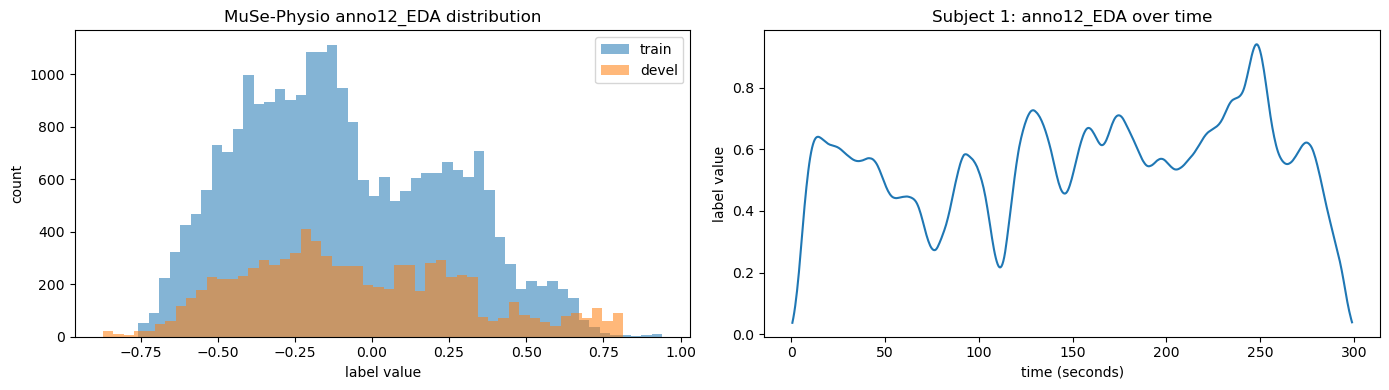

In [21]:
if not HAS_MATPLOTLIB:
    print("Skipping plots because Matplotlib is unavailable.")
else:
    task_name = "MuSe-Physio"
    label_name = TASKS[task_name]["primary_target"]
    fig, axes = plt.subplots(1, 2, figsize=(14, 4))

    for split in ["train", "devel"]:
        ids = read_partition(task_name).query("Proposal == @split")["Id"].tolist()
        vals = []
        for sid in ids:
            df = read_label_csv(task_name, label_name, int(sid))
            vals.extend(pd.to_numeric(df["value"], errors="coerce").dropna().tolist())
        axes[0].hist(vals, bins=50, alpha=0.55, label=split)
    axes[0].set_title(f"{task_name} {label_name} distribution")
    axes[0].set_xlabel("label value")
    axes[0].set_ylabel("count")
    axes[0].legend()

    sample_labels = read_label_csv(task_name, label_name, SAMPLE_SUBJECT_ID)
    axes[1].plot(sample_labels["timestamp"] / 1000.0, pd.to_numeric(sample_labels["value"], errors="coerce"), linewidth=1.5)
    axes[1].set_title(f"Subject {SAMPLE_SUBJECT_ID}: {label_name} over time")
    axes[1].set_xlabel("time (seconds)")
    axes[1].set_ylabel("label value")
    plt.tight_layout()
    plt.show()

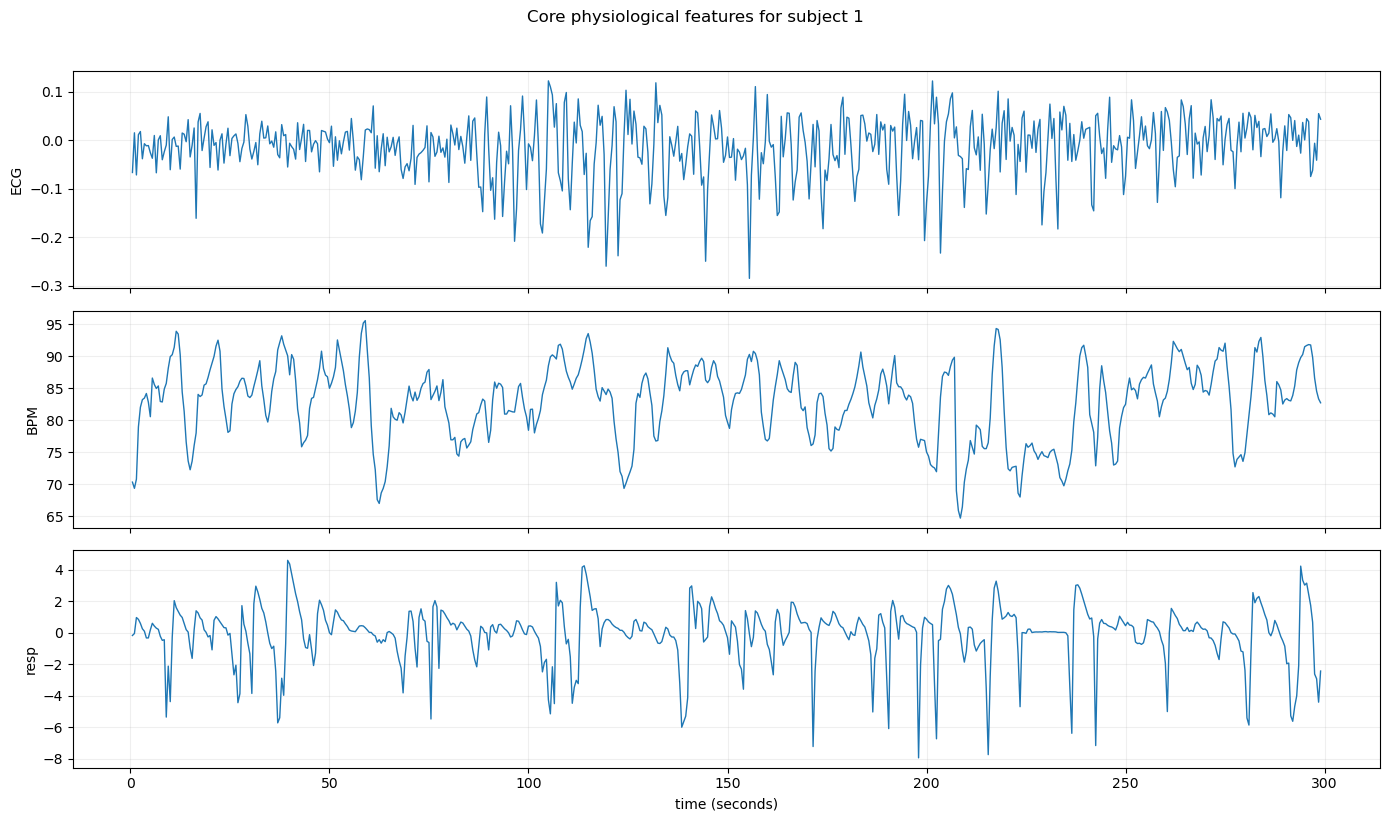

In [22]:
if not HAS_MATPLOTLIB:
    print("Skipping plots because Matplotlib is unavailable.")
else:
    task_name = "MuSe-Physio"
    fig, axes = plt.subplots(len(CORE_PHYSIO_FEATURES), 1, figsize=(14, 8), sharex=True)
    if len(CORE_PHYSIO_FEATURES) == 1:
        axes = [axes]
    for ax, feature in zip(axes, CORE_PHYSIO_FEATURES):
        df = read_feature_csv(task_name, feature, SAMPLE_SUBJECT_ID)
        feature_col = [c for c in df.columns if c not in ["timestamp", "segment_id"]][0]
        ax.plot(df["timestamp"] / 1000.0, pd.to_numeric(df[feature_col], errors="coerce"), linewidth=1)
        ax.set_ylabel(feature)
        ax.grid(alpha=0.2)
    axes[-1].set_xlabel("time (seconds)")
    fig.suptitle(f"Core physiological features for subject {SAMPLE_SUBJECT_ID}", y=1.02)
    plt.tight_layout()
    plt.show()

## 11. Optional Deep Scan

The default notebook avoids reading every high-dimensional CSV because `deepspectrum`, `bert`, and `vggface` can be slow and memory-heavy. Set `DEEP_SCAN = True` only when you want a full pass over all subjects and selected features.

In [24]:
DEEP_SCAN = True
DEEP_SCAN_FEATURES = CORE_PHYSIO_FEATURES  # Change this carefully if you want to include high-dimensional modalities.

if not DEEP_SCAN:
    print("Deep scan skipped. Set DEEP_SCAN = True to scan selected features across all subjects.")
else:
    deep_rows = []
    for task_name in TASKS:
        for subject_id in subject_ids_by_task[task_name]:
            for feature in DEEP_SCAN_FEATURES:
                try:
                    df = read_feature_csv(task_name, feature, subject_id)
                    feature_cols = [c for c in df.columns if c not in ["timestamp", "segment_id"]]
                    values = df[feature_cols].apply(pd.to_numeric, errors="coerce")
                    ts_info = timestamp_summary(df)
                    deep_rows.append({
                        "task": task_name, "subject_id": subject_id, "feature": feature,
                        "rows": len(df), "dims": len(feature_cols), "missing_values": int(values.isna().sum().sum()),
                        "timestamp_start": ts_info.get("start"), "timestamp_end": ts_info.get("end"),
                        "median_step_ms": ts_info.get("median_step"), "error": None,
                    })
                except Exception as exc:
                    deep_rows.append({"task": task_name, "subject_id": subject_id, "feature": feature, "rows": None, "dims": None, "missing_values": None, "timestamp_start": None, "timestamp_end": None, "median_step_ms": None, "error": repr(exc)})
    deep_scan_results = pd.DataFrame(deep_rows)
    display(deep_scan_results.groupby(["task", "feature"], as_index=False).agg(
        subjects=("subject_id", "count"), min_rows=("rows", "min"), max_rows=("rows", "max"),
        total_missing_values=("missing_values", "sum"), median_step_ms=("median_step_ms", "median"),
        errors=("error", lambda s: sorted(set(x for x in s.dropna() if x))),
    ))

,task,feature,subjects,min_rows,max_rows,total_missing_values,median_step_ms,errors
0,MuSe-Physio,BPM,69,542,748,0,500.0,[]
1,MuSe-Physio,ECG,69,542,748,0,500.0,[]
2,MuSe-Physio,resp,69,542,748,0,500.0,[]
3,MuSe-Stress,BPM,69,542,748,0,500.0,[]
4,MuSe-Stress,ECG,69,542,748,0,500.0,[]
5,MuSe-Stress,resp,69,542,748,0,500.0,[]
